# O Problema

## Contexto

Este notebook investiga a relação entre alucinações produzidas por LLMs na geração de código e violações de regras detectadas pelo SonarQube. O objetivo é entender se determinados tipos de alucinação tendem a se manifestar junto com determinadas regras de qualidade de código e, em que nível essa associação ocorre.

## Dados utilizados

Os dados que serão utilizados foram obtido a partir do trabalho de Liu, em que 624 tarefas foram selecionadas de vários datasets, cada tarefa foi submetida com o memso prompt por 5 LLM's distintas. Isso resultou em 3120 implementações de códigos.

Essa implementação foi avaliada com relação à existência ou não de alucinação e, a partir daí foram classficadas as alucinações conforme a taxonomia do trabalho de Liu. Essas alucinações foram classficadas seguindo uma metodologia citada no artigo.

A partir daí, nosso trabalho detectou alertas do SonarQube dessas implementações e, foram classificados em 60 alertas distintos.

## Questões de Pesquisa

> Questão 1: Olhando para cada implementação de código individualmente: as implementações que têm a alucinação X são mais propensas a também ter a violação da regra Y do que as implementações que não têm a alucinação X?

> Questão 2: Tarefas que manifestam alucinação do tipo X (em alguma de suas implementações) tendem a manifestar a violação da regra Y (em alguma de suas implementações)?

## Objetivo geral 

Identificar, para os 720 pares (alucinação × regra), quais associações são estatisticamente significativas e praticamente relevantes, em ambos os níveis de análise, controlando dependência, confundimento e múltiplas comparações.

## Desafios metodológicos

- Dependẽncia: As implementações da mesma tarefa não são independentes pois vêm do mesmo prompt. Por exemplo, se o prompt é diícil todas podem alucinar, se o prompt é fácil pode ser que nenhuma alucine. O erro padrão assume independência e, se isso for ignorado, o erro padrão fica subestimado e o p-valor fica menor do que deveria. Isso pode causar falsos positivos.

- Confundimento: LLM, dataset e level podem afetar tanto alucinação quanto alerta. Por exemplo, Pode ser que alguma LLM alucine mais que outras, ou que dataset, levels ou project diferentes tenham complexidades de tarefas diferentes. 

## Metodologia

### Fase 1 — Preparação dos dados

1.1 Explodir as listas sonar_rules e hallucination_types para colunas binárias.

1.2  Construir a matriz no nível da implementação (3.120 linhas × 12 alucinações + 60 regras).

1.3  Construir a matriz no nível da tarefa (624 linhas × 12 alucinações + 60 regras, critério any).

### Fase 2 — Nível da implementação (QP1)

2.1 Filtro de viabilidade: manter pares (X, Y) com ≥ N ocorrências de X e de Y (definir N).

2.2 Análise exploratória: tabela 2×2 + Fisher + OR + IC 95% (p-valor não inferencial, pois ignora dependência).

2.3 Análise primária: GLMM logístico
    regra_Y ~ aluc_X + model + dataset + level + (1 | tarefa)
    Usar Firth/penalização em caso de separação; reportar não convergências.

2.4 Moderação: teste de razão de verossimilhança entre o modelo acima e o modelo com aluc_X:model.

2.5 FDR (Benjamini-Hochberg) sobre os p-valores do GLMM (2.3).

### Fase 3 — Nível da tarefa (QP2)

3.1 Filtro de viabilidade análogo ao da Fase 2.

3.2 Exploratória: 2×2 + Fisher + OR + IC 95%.

3.3 Primária: GLM logístico com dataset e level (e, opcionalmente, nº de implementações alucinadas).

3.4 FDR sobre os p-valores de 3.3.

3.5 Sensibilidade: critério majority.

### Fase 4 — Síntese (OE5, OE6)

4.1 Comparar os achados das duas análises (interseção, divergências).

4.2 Gerar heatmap 12 × 60, forest plots e Análise de Correspondência.



## Fase 1: Preparação dos dados

# Dados

## Carregamento dos dados

In [28]:
from pathlib import Path
import json
import math
from collections import Counter, defaultdict
from IPython.display import Markdown, display

import pandas as pd

START_DIR = Path.cwd().resolve()
DATA_DIR = (START_DIR.parent if START_DIR.name == "statistical_analysis" else START_DIR) / "artifacts"

INPUT_JSONL = DATA_DIR / "metadata.jsonl"
MAPPED_ISSUES = DATA_DIR / "mapped_issues.json"

print("Pasta dos dados:", DATA_DIR)
print("metadata.jsonl:", INPUT_JSONL)
print("mapped_issues.json:", MAPPED_ISSUES)

## Análise de dados

In [29]:
input_rows = []
with INPUT_JSONL.open(encoding="utf-8") as f:
    for row_number, line in enumerate(f, start=1):
        obj = json.loads(line)
        input_rows.append((row_number, obj))

with MAPPED_ISSUES.open(encoding="utf-8") as f:
    mapped_issues = json.load(f)

issues_by_row = defaultdict(list)
for issue in mapped_issues:
    issues_by_row[int(issue["row_number"])].append(issue)

print("Respostas em metadata.jsonl:", len(input_rows))
print("Issues SonarQube mapeadas:", len(mapped_issues))
print("Respostas com pelo menos uma issue:", len(issues_by_row))

Respostas em metadata.jsonl: 3120
Issues SonarQube mapeadas: 1426
Respostas com pelo menos uma issue: 838


In [30]:
expected_task_count = 624
expected_models_per_task = 5

tasks_by_id = defaultdict(list)
missing_id_rows = []
for row_number, obj in input_rows:
    task_id = obj.get("_id")
    if task_id is None or (isinstance(task_id, str) and not task_id.strip()):
        missing_id_rows.append(row_number)
        continue
    tasks_by_id[task_id].append(obj.get("model"))

invalid_tasks = {}
for task_id, models in tasks_by_id.items():
    valid_models = [
        model for model in models
        if isinstance(model, str) and model.strip()
    ]
    if (
        len(models) != expected_models_per_task
        or len(valid_models) != expected_models_per_task
        or len(set(valid_models)) != expected_models_per_task
    ):
        invalid_tasks[task_id] = models

print("Tarefas distintas:", len(tasks_by_id))
print("Registros sem _id:", len(missing_id_rows))
print("Tarefas fora do critério:", len(invalid_tasks))

if (
    len(tasks_by_id) != expected_task_count
    or missing_id_rows
    or invalid_tasks
):
    raise ValueError(
        "A validação falhou. "
        f"Esperadas {expected_task_count} tarefas, cada uma com "
        f"{expected_models_per_task} registros e modelos não vazios distintos. "
        f"Linhas sem _id: {missing_id_rows[:10]}; "
        f"tarefas inválidas: {list(invalid_tasks.items())[:10]}"
    )

print("Verificação aprovada: cada tarefa tem cinco modelos distintos.")

Tarefas distintas: 624
Registros sem _id: 0
Tarefas fora do critério: 0
Verificação aprovada: cada tarefa tem cinco modelos distintos.


In [31]:
records = []
for row_number, obj in input_rows:
    labels = obj.get("code_labels") or []
    hallucination_types = sorted({
        label.get("hallucination-type")
        for label in labels
        if label.get("hallucination-type")
    })
    affections = sorted({
        affection
        for label in labels
        for affection in (label.get("affections") or [])
        if affection
    })
    issues = issues_by_row.get(row_number, [])
    records.append({
        "row_number": row_number,
        "_id": obj.get("_id"),
        "model": obj.get("model"),
        "dataset": obj.get("dataset"),
        "project": obj.get("project"),
        "has_sonar_issue": bool(issues),
        "sonar_issue_count": len(issues),
        "sonar_rules": sorted({issue.get("sonar_rule") for issue in issues if issue.get("sonar_rule")}),
        "sonar_types": sorted({issue.get("sonar_type") for issue in issues if issue.get("sonar_type")}),
        "sonar_severities": sorted({issue.get("severity") for issue in issues if issue.get("severity")}),
        "hallucination_types": hallucination_types,
        "affections": affections,
    })

df = pd.DataFrame(records)
df.head()

,row_number,_id,model,dataset,project,has_sonar_issue,sonar_issue_count,sonar_rules,sonar_types,sonar_severities,hallucination_types,affections
0,1,636767191a6d9265ec017c0f,deepseek-coder-1.3b,CEJava,hasor-master,True,2,[java:S1854],[CODE_SMELL],[MAJOR],[],[]
1,2,636767191a6d9265ec017c0f,deepseek-coder-7b,CEJava,hasor-master,False,0,[],[],[],[],[]
2,3,636767191a6d9265ec017c0f,codellama-7b,CEJava,hasor-master,True,2,[java:S1854],[CODE_SMELL],[MAJOR],[],[]
3,4,636767191a6d9265ec017c0f,gpt-4,CEJava,hasor-master,True,1,[java:S1144],[CODE_SMELL],[MAJOR],[],[]
4,5,636767191a6d9265ec017c0f,deepseek-r1,CEJava,hasor-master,True,2,[java:S1854],[CODE_SMELL],[MAJOR],[Library/Project],[Incorrect Functionality]


In [32]:
#verificar se há duplicatas de (_id, model) no DataFrame
df.duplicated(subset=["_id", "model"]).sum()

np.int64(0)

In [33]:
#verificar se há valores nulos nas colunas _id, model, dataset e level
df[["_id", "model", "dataset"]].isna().sum()

_id        0
model      0
dataset    0
dtype: int64

In [34]:
# verificar tipos de alucinação distintos
hallucination_types = sorted({
    h
    for values in df["hallucination_types"]
    for h in values
})

len(hallucination_types), hallucination_types

(12,
 ['Algorithm',
  'Behavior Conflicting',
  'Common Sense',
  'Computer Theory',
  'Data Conflicting',
  'Fragmented Logics',
  'Inconsistent Libraries',
  'Library/Project',
  'Mathematics & Natural Science',
  'Undefined Variables',
  'Useless Statements (executed without effect)',
  'Useless Statements (unexecuted)'])

In [35]:
# verificar tipos de sonar_rules distintos
sonar_rules_full = sorted({
    r
    for values in df["sonar_rules"]
    for r in values
})

len(sonar_rules_full), sonar_rules_full

(71,
 ['java:S106',
  'java:S1066',
  'java:S1075',
  'java:S112',
  'java:S1125',
  'java:S1126',
  'java:S1130',
  'java:S1135',
  'java:S1144',
  'java:S1149',
  'java:S1168',
  'java:S117',
  'java:S1172',
  'java:S1192',
  'java:S1197',
  'java:S1206',
  'java:S125',
  'java:S127',
  'java:S135',
  'java:S1481',
  'java:S1488',
  'java:S1604',
  'java:S1659',
  'java:S1854',
  'java:S1871',
  'java:S2129',
  'java:S2189',
  'java:S2293',
  'java:S3012',
  'java:S3358',
  'java:S3626',
  'java:S3740',
  'java:S3776',
  'java:S4719',
  'java:S5738',
  'java:S6201',
  'java:S6208',
  'python:S1066',
  'python:S112',
  'python:S1135',
  'python:S117',
  'python:S1172',
  'python:S1192',
  'python:S1226',
  'python:S1481',
  'python:S1542',
  'python:S1656',
  'python:S1854',
  'python:S1862',
  'python:S1871',
  'python:S2190',
  'python:S2275',
  'python:S3358',
  'python:S3457',
  'python:S3776',
  'python:S3827',
  'python:S3923',
  'python:S5361',
  'python:S5603',
  'python:S5754

In [36]:
sonar_rules_number = {
    rule.split(":")[-1]
    for rules in df["sonar_rules"]
    for rule in rules
}

print("Chaves completas:", len(sonar_rules_full))
print("IDs Sxxxx:", len(sonar_rules_number))

Chaves completas: 71
IDs Sxxxx: 60


In [37]:
from collections import defaultdict

rule_languages = defaultdict(set)

for rules in df["sonar_rules"]:
    for rule in rules:
        language, rule_id = rule.split(":")
        rule_languages[rule_id].add(language)

shared = {
    rule_id: languages
    for rule_id, languages in rule_languages.items()
    if len(languages) > 1
}

shared

{'S1854': {'java', 'python'},
 'S117': {'java', 'python'},
 'S3776': {'java', 'python'},
 'S1172': {'java', 'python'},
 'S1066': {'java', 'python'},
 'S1871': {'java', 'python'},
 'S112': {'java', 'python'},
 'S1135': {'java', 'python'},
 'S1481': {'java', 'python'},
 'S1192': {'java', 'python'},
 'S3358': {'java', 'python'}}

In [38]:
shared_rules = []

for rule_id, languages in rule_languages.items():
    if len(languages) > 1:
        shared_rules.append({
            "rule_id": rule_id,
            "languages": sorted(languages)
        })

shared_rules

[{'rule_id': 'S1854', 'languages': ['java', 'python']},
 {'rule_id': 'S117', 'languages': ['java', 'python']},
 {'rule_id': 'S3776', 'languages': ['java', 'python']},
 {'rule_id': 'S1172', 'languages': ['java', 'python']},
 {'rule_id': 'S1066', 'languages': ['java', 'python']},
 {'rule_id': 'S1871', 'languages': ['java', 'python']},
 {'rule_id': 'S112', 'languages': ['java', 'python']},
 {'rule_id': 'S1135', 'languages': ['java', 'python']},
 {'rule_id': 'S1481', 'languages': ['java', 'python']},
 {'rule_id': 'S1192', 'languages': ['java', 'python']},
 {'rule_id': 'S3358', 'languages': ['java', 'python']}]

Irei manter a chave completa como regra, isto é, java:S1854 e python:S1854 como variáveis diferentes na análise principal porque juntar regras entre linguagens poderia criar uma outra variável cuja detecção de associações pode mudar conforme a linguagem. Esse não é o objetivo no momento.

In [39]:
# Frequencia de cada regra do SonarQube no conjunto de dados
sonar_freq = (
    df["sonar_rules"]
    .explode()
    .dropna()
    .value_counts()
    .rename_axis("sonar_rule")
    .reset_index(name="n_implementacoes")
)

sonar_freq.head(20)

,sonar_rule,n_implementacoes
0,java:S1854,371
1,python:S1172,87
2,java:S1144,68
3,python:S1542,61
4,python:S3776,37
5,python:S1481,30
6,python:S1854,26
7,java:S1168,25
8,java:S1172,25
9,java:S106,21


In [40]:
halluc_freq = (
    df["hallucination_types"]
    .explode()
    .dropna()
    .value_counts()
    .rename_axis("hallucination_type")
    .reset_index(name="n_implementacoes")
)

halluc_freq

,hallucination_type,n_implementacoes
0,Behavior Conflicting,420
1,Library/Project,309
2,Undefined Variables,200
3,Useless Statements (executed without effect),71
4,Algorithm,60
5,Data Conflicting,50
6,Computer Theory,27
7,Fragmented Logics,21
8,Mathematics & Natural Science,17
9,Useless Statements (unexecuted),7


In [42]:
sonar_freq["percentual"] = (
    100 * sonar_freq["n_implementacoes"] / len(df)
)

halluc_freq["percentual"] = (
    100 * halluc_freq["n_implementacoes"] / len(df)
)

In [43]:
sonar_freq.sort_values("n_implementacoes")

,sonar_rule,n_implementacoes,percentual
60,python:S2275,1,0.032051
61,python:S1135,1,0.032051
51,java:S1481,1,0.032051
50,java:S1871,1,0.032051
54,java:S3358,1,0.032051
...,...,...,...
4,python:S3776,37,1.185897
3,python:S1542,61,1.955128
2,java:S1144,68,2.179487
1,python:S1172,87,2.788462


In [44]:
halluc_freq.sort_values("n_implementacoes")

,hallucination_type,n_implementacoes,percentual
11,Inconsistent Libraries,2,0.064103
10,Common Sense,3,0.096154
9,Useless Statements (unexecuted),7,0.224359
8,Mathematics & Natural Science,17,0.544872
7,Fragmented Logics,21,0.673077
6,Computer Theory,27,0.865385
5,Data Conflicting,50,1.602564
4,Algorithm,60,1.923077
3,Useless Statements (executed without effect),71,2.275641
2,Undefined Variables,200,6.410256


### 1.1 Colunas binárias

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

# Binarização das colunas de hallucination_types
mlb_halluc = MultiLabelBinarizer()

halluc_binary = pd.DataFrame(
    mlb_halluc.fit_transform(df["hallucination_types"]),
    columns=["halluc_" + x for x in mlb_halluc.classes_],
    index=df.index
)

halluc_binary.head()

,halluc_Algorithm,halluc_Behavior Conflicting,halluc_Common Sense,halluc_Computer Theory,halluc_Data Conflicting,halluc_Fragmented Logics,halluc_Inconsistent Libraries,halluc_Library/Project,halluc_Mathematics & Natural Science,halluc_Undefined Variables,halluc_Useless Statements (executed without effect),halluc_Useless Statements (unexecuted)
0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0,0,0


In [ ]:
# Binarização das colunas de sonar_rules
mlb_sonar = MultiLabelBinarizer()

sonar_binary = pd.DataFrame(
    mlb_sonar.fit_transform(df["sonar_rules"]),
    columns=["sonar_" + x for x in mlb_sonar.classes_],
    index=df.index
)

sonar_binary.head()

,sonar_java:S106,sonar_java:S1066,sonar_java:S1075,sonar_java:S112,sonar_java:S1125,sonar_java:S1126,sonar_java:S1130,sonar_java:S1135,sonar_java:S1144,sonar_java:S1149,...,sonar_python:S5806,sonar_python:S5855,sonar_python:S5864,sonar_python:S5869,sonar_python:S6019,sonar_python:S6326,sonar_python:S6353,sonar_python:S6395,sonar_python:S6397,sonar_python:S930
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 1.2  Matriz no nível da implementação

O dataset no nível da implementação contém 3.120 observações, em que cada linha representa uma implementação de código gerada por uma LLM para uma determinada tarefa. As 624 tarefas foram submetidas a cinco LLMs, resultando em cinco implementações por tarefa.

Cada implementação é identificada pela tarefa `_id` e pelo modelo responsável por sua geração `model`. O dataset também preserva informações sobre a origem da tarefa (`dataset` e `project`).

Os tipos de alucinação e as regras do SonarQube foram representados por variáveis binárias. Para cada um dos 12 tipos de alucinação, o valor 1 indica que a implementação foi classificada com aquele tipo de alucinação, enquanto 0 indica sua ausência. Analogamente, para cada uma das 71 regras do SonarQube, o valor 1 indica que pelo menos uma ocorrência daquela regra foi detectada na implementação e 0 indica que a regra não foi detectada.

Esse dataset permite investigar se, em uma mesma implementação, a presença de determinado tipo de alucinação está associada à presença de determinada violação do SonarQube. Como as cinco implementações correspondentes à mesma tarefa compartilham o mesmo prompt, elas não são consideradas observações independentes.

In [57]:
# Junção dos DataFrames binarizados com o DataFrame original
df_bin = pd.concat(
    [
        df[[
            "row_number",
            "_id",
            "model",
            "dataset",
            "project"
        ]],
        halluc_binary,
        sonar_binary
    ],
    axis=1
)

In [69]:
freq_X_impl = df_bin[halluc_cols].sum()
freq_Y_impl = df_bin[sonar_cols].sum()
print("Frequência de cada tipo de alucinação (X):")
print()
print("\nFrequência de cada regra do SonarQube (Y):")
print(freq_Y_impl)           

Frequência de cada tipo de alucinação (X):
halluc_Algorithm                                        60
halluc_Behavior Conflicting                            420
halluc_Common Sense                                      3
halluc_Computer Theory                                  27
halluc_Data Conflicting                                 50
halluc_Fragmented Logics                                21
halluc_Inconsistent Libraries                            2
halluc_Library/Project                                 309
halluc_Mathematics & Natural Science                    17
halluc_Undefined Variables                             200
halluc_Useless Statements (executed without effect)     71
halluc_Useless Statements (unexecuted)                   7
dtype: int64

Frequência de cada regra do SonarQube (Y):
sonar_java:S106       21
sonar_java:S1066       4
sonar_java:S1075       2
sonar_java:S112        7
sonar_java:S1125       2
                      ..
sonar_python:S6326     1
sonar_python:S635

### 1.3  Matriz no nível da tarefa

O dataset no nível da tarefa contém 624 observações, em que cada linha representa uma tarefa. Ele foi obtido pela agregação das cinco implementações geradas para cada tarefa no dataset no nível da implementação.

Para cada tipo de alucinação e regra do SonarQube foi utilizado, na análise principal, o critério `any`. Assim, uma tarefa recebe valor 1 para um determinado tipo de alucinação quando esse tipo ocorre em pelo menos uma das cinco implementações da tarefa, e valor 0 quando não ocorre em nenhuma delas. Da mesma forma, uma tarefa recebe valor 1 para uma regra do SonarQube quando a regra é detectada em pelo menos uma das cinco implementações e valor 0 quando não é detectada em nenhuma delas.

Consequentemente, a coocorrência de uma alucinação X e uma regra Y no nível da tarefa não implica que ambas tenham ocorrido na mesma implementação. Ela indica que a tarefa apresentou X em pelo menos uma de suas implementações e Y em pelo menos uma de suas implementações.

Esse dataset permite investigar se tarefas que manifestam determinado tipo de alucinação também tendem a manifestar determinada violação do SonarQube.

In [65]:
halluc_cols = list(halluc_binary.columns)
sonar_cols = list(sonar_binary.columns)
binary_cols = halluc_cols + sonar_cols

In [ ]:
# Mostra se cada tarefa, independente da LLM, teve algum tipo de alucinação e alguma regra SonarQube
df_task_binary = (
    df_bin
    .groupby("_id")[binary_cols]
    .max()
    .reset_index()
)
print("Número de tarefas:", df_task_binary)

Número de tarefas:                           _id  halluc_Algorithm  halluc_Behavior Conflicting  \
0    62b43425903eeb48555d3ea1                 0                            1   
1    62b43426903eeb48555d3ea2                 0                            0   
2    62b43427903eeb48555d3ea5                 0                            1   
3    62b43428903eeb48555d3eaa                 0                            0   
4    62b438a266fea644fe22cc2c                 0                            0   
..                        ...               ...                          ...   
619              HumanEval/95                 0                            0   
620              HumanEval/96                 0                            1   
621              HumanEval/97                 0                            1   
622              HumanEval/98                 0                            0   
623              HumanEval/99                 0                            0   

     halluc_Common S

In [ ]:
# Dataset e projeto de cada task
task_info = (
    df_bin
    .groupby("_id")
    .agg(
        dataset=("dataset", "first"),
        project=("project", "first")
    )
    .reset_index()
)

print(task_info)

                          _id    dataset                        project
0    62b43425903eeb48555d3ea1   CEPython  cpburnz/python-sql-parameters
1    62b43426903eeb48555d3ea2   CEPython  cpburnz/python-sql-parameters
2    62b43427903eeb48555d3ea5   CEPython  cpburnz/python-sql-parameters
3    62b43428903eeb48555d3eaa   CEPython  cpburnz/python-sql-parameters
4    62b438a266fea644fe22cc2c   CEPython               witten/borgmatic
..                        ...        ...                            ...
619              HumanEval/95  HumanEval                            NaN
620              HumanEval/96  HumanEval                            NaN
621              HumanEval/97  HumanEval                            NaN
622              HumanEval/98  HumanEval                            NaN
623              HumanEval/99  HumanEval                            NaN

[624 rows x 3 columns]


In [ ]:
# Dataset completo com informações de alucinação e SonarQube por tarefa
df_task = task_info.merge(
    df_task_binary,
    on="_id"
)

print(df_task)

                          _id    dataset                        project  \
0    62b43425903eeb48555d3ea1   CEPython  cpburnz/python-sql-parameters   
1    62b43426903eeb48555d3ea2   CEPython  cpburnz/python-sql-parameters   
2    62b43427903eeb48555d3ea5   CEPython  cpburnz/python-sql-parameters   
3    62b43428903eeb48555d3eaa   CEPython  cpburnz/python-sql-parameters   
4    62b438a266fea644fe22cc2c   CEPython               witten/borgmatic   
..                        ...        ...                            ...   
619              HumanEval/95  HumanEval                            NaN   
620              HumanEval/96  HumanEval                            NaN   
621              HumanEval/97  HumanEval                            NaN   
622              HumanEval/98  HumanEval                            NaN   
623              HumanEval/99  HumanEval                            NaN   

     halluc_Algorithm  halluc_Behavior Conflicting  halluc_Common Sense  \
0                   0   

In [62]:
df_task.shape

(624, 86)

In [70]:
freq_X_task = df_task_binary[halluc_cols].sum()
freq_Y_task = df_task_binary[sonar_cols].sum()
print(f"Frequência de cada tipo de alucinação (X) por tarefa: {freq_X_task}")
print(f"Frequência de cada regra do SonarQube (Y) por tarefa: {freq_Y_task}")

Frequência de cada tipo de alucinação (X) por tarefa: halluc_Algorithm                                        34
halluc_Behavior Conflicting                            228
halluc_Common Sense                                      1
halluc_Computer Theory                                  20
halluc_Data Conflicting                                 32
halluc_Fragmented Logics                                19
halluc_Inconsistent Libraries                            2
halluc_Library/Project                                 217
halluc_Mathematics & Natural Science                    11
halluc_Undefined Variables                             113
halluc_Useless Statements (executed without effect)     41
halluc_Useless Statements (unexecuted)                   6
dtype: int64
Frequência de cada regra do SonarQube (Y) por tarefa: sonar_java:S106       15
sonar_java:S1066       4
sonar_java:S1075       2
sonar_java:S112        5
sonar_java:S1125       2
                      ..
sonar_python:S6326   

### 2.1 Filtro de viabilidade

Para saber se há informação suficiente nos dados para estimar de forma confiável a associação entre cada alucinação \(X\) e cada regra \(Y\), vamos análisar o número de ocorrencias simultâneas entre alucinação e alerta do SonarQube. Essa análise será usada como uma direção para os testes estatísticos.

O processo da aanálise será:
1. Avaliar a disponibilidade de informações
2. Determinar pares de alucinações e alertas analisáveis


Para cada halluc_cols e sonar_cols, define `a`, `b`, `c` e `d`, em que 
- `a` representa o número de vezes que aconteceu `halluc_cols` e `sonar_cols`
- `b` representa o número de vezes que aconteceu `halluc_cols` e não ocorreu `sonar_cols`
- `c` representa o número de vezes que aconteceu `sonar_cols` e nao ocorreu `halluc_cols` 
- `d` representa o núemro de vezes que não aconteceu ambas .



In [86]:
rows = []

for X in halluc_cols:
    for Y in sonar_cols:

        a = ((df_bin[X] == 1) & (df_bin[Y] == 1)).sum()
        b = ((df_bin[X] == 1) & (df_bin[Y] == 0)).sum()
        c = ((df_bin[X] == 0) & (df_bin[Y] == 1)).sum()
        d = ((df_bin[X] == 0) & (df_bin[Y] == 0)).sum()

        rows.append({
            "hallucination": X,
            "sonar_rule": Y,
            "a_X1Y1": a,
            "b_X1Y0": b,
            "c_X0Y1": c,
            "d_X0Y0": d,
            "n_X": a + b,
            "n_Y": a + c
        })

viability_impl = pd.DataFrame(rows)
print(viability_impl.head(1))

      hallucination       sonar_rule  a_X1Y1  b_X1Y0  c_X0Y1  d_X0Y0  n_X  n_Y
0  halluc_Algorithm  sonar_java:S106       0      60      21    3039   60   21


In [87]:
viability_impl["a_X1Y1"].describe()

count    852.000000
mean       0.566901
std        3.775919
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       71.000000
Name: a_X1Y1, dtype: float64

In [88]:
viability_impl["a_X1Y1"].value_counts().sort_index()

a_X1Y1
0     732
1      67
2      18
3      12
4       3
5       3
6       3
7       3
8       1
9       1
10      1
12      1
14      1
15      1
16      1
21      1
47      1
55      1
71      1
Name: count, dtype: int64

In [89]:
rows = []

for X in halluc_cols:
    for Y in sonar_cols:

        a = ((df_task_binary[X] == 1) &
             (df_task_binary[Y] == 1)).sum()

        b = ((df_task_binary[X] == 1) &
             (df_task_binary[Y] == 0)).sum()

        c = ((df_task_binary[X] == 0) &
             (df_task_binary[Y] == 1)).sum()

        d = ((df_task_binary[X] == 0) &
             (df_task_binary[Y] == 0)).sum()

        rows.append({
            "hallucination": X,
            "sonar_rule": Y,
            "a_X1Y1": a,
            "b_X1Y0": b,
            "c_X0Y1": c,
            "d_X0Y0": d,
            "n_X": a + b,
            "n_Y": a + c
        })

viability_task = pd.DataFrame(rows)

In [90]:
# Verifica o número de vezes que ocorre alucinação e regra do SonarQube na mesma implementação
def resumo_coocorrencias(df):
    total = len(df)
    a = df["a_X1Y1"]

    resultados = {
        "zero ocorrencias simultâneas": (a == 0).sum(),
        "até 1 ocorrencia simultânea": (a <= 1).sum(),
        "ate 5 ocorrencias simultâneas": (a <= 5).sum(),
        "ate 10 ocorrencias simultâneas": (a <= 10).sum(),
        "mais de 20 ocorrencias simultâneas": (a > 20).sum()
    }

    for criterio, n in resultados.items():
        percentual = 100 * n / total
        print(f"{criterio}: {n}/{total} ({percentual:.1f}%)")

resumo_coocorrencias(viability_impl)

zero ocorrencias simultâneas: 732/852 (85.9%)
até 1 ocorrencia simultânea: 799/852 (93.8%)
ate 5 ocorrencias simultâneas: 835/852 (98.0%)
ate 10 ocorrencias simultâneas: 844/852 (99.1%)
mais de 20 ocorrencias simultâneas: 4/852 (0.5%)


In [91]:
resumo_coocorrencias(viability_task)

zero ocorrencias simultâneas: 622/852 (73.0%)
até 1 ocorrencia simultânea: 754/852 (88.5%)
ate 5 ocorrencias simultâneas: 825/852 (96.8%)
ate 10 ocorrencias simultâneas: 839/852 (98.5%)
mais de 20 ocorrencias simultâneas: 7/852 (0.8%)


Note que:
- 4 pares de regras do SonarQube e alucinação ocorrem em mais 7 implementações
- 732 pares de regras não ocorrem em nenhuma implentação.
Não podem ser descartados esses pares de regras que não possuem nenhuma coocorrencia pois, isso pode indicar uma consequencia estrutural, como pertencimento em subconjuntos incompatíveis de dados, por exemplo.

Verificaremos as frequências por dataset e, quais regras aparecem em cada dataset


In [92]:
# Frequências por datase
pd.crosstab(
    df_bin["dataset"],
    df_bin["model"]
)


model,codellama-7b,deepseek-coder-1.3b,deepseek-coder-7b,deepseek-r1,gpt-4
dataset,,,,,
CEJava,230,230,230,230,230
CEPython,230,230,230,230,230
HumanEval,164,164,164,164,164


In [93]:
for dataset in df_bin["dataset"].unique():

    subset = df_bin[df_bin["dataset"] == dataset]

    active_rules = [
        col for col in sonar_cols
        if subset[col].sum() > 0
    ]

    print(f"\n{dataset}: {len(active_rules)} regras")
    print(active_rules)


CEJava: 37 regras
['sonar_java:S106', 'sonar_java:S1066', 'sonar_java:S1075', 'sonar_java:S112', 'sonar_java:S1125', 'sonar_java:S1126', 'sonar_java:S1130', 'sonar_java:S1135', 'sonar_java:S1144', 'sonar_java:S1149', 'sonar_java:S1168', 'sonar_java:S117', 'sonar_java:S1172', 'sonar_java:S1192', 'sonar_java:S1197', 'sonar_java:S1206', 'sonar_java:S125', 'sonar_java:S127', 'sonar_java:S135', 'sonar_java:S1481', 'sonar_java:S1488', 'sonar_java:S1604', 'sonar_java:S1659', 'sonar_java:S1854', 'sonar_java:S1871', 'sonar_java:S2129', 'sonar_java:S2189', 'sonar_java:S2293', 'sonar_java:S3012', 'sonar_java:S3358', 'sonar_java:S3626', 'sonar_java:S3740', 'sonar_java:S3776', 'sonar_java:S4719', 'sonar_java:S5738', 'sonar_java:S6201', 'sonar_java:S6208']

CEPython: 32 regras
['sonar_python:S1066', 'sonar_python:S112', 'sonar_python:S1135', 'sonar_python:S117', 'sonar_python:S1172', 'sonar_python:S1192', 'sonar_python:S1226', 'sonar_python:S1481', 'sonar_python:S1542', 'sonar_python:S1656', 'sonar

Isso mostra que CEJava só apresenta java e, CEPython e HumanEval apresentam python.

Vamos reimplementar as tabelas 2x2 dentro das implementações nas quais aquela regra SonarQube poderia ocorrer.

Em seguida vamos refazer a análise de esparsidade das coocorrências das regras do SonarQube com as alucinações.


In [ ]:
# Mostra a quantidade de implementações por dataset e modelo
def get_eligible_subset(df, sonar_rule):
    if sonar_rule.startswith("sonar_java:"):
        return df[df["dataset"] == "CEJava"]

    elif sonar_rule.startswith("sonar_python:"):
        return df[df["dataset"].isin(["CEPython", "HumanEval"])]

    else:
        raise ValueError(f"Linguagem não identificada: {sonar_rule}")

In [ ]:
# Tabela de contingência para cada par de alucinação e regra do SonarQube, X indica alucinação e Y indica regra do SonarQube.
rows = []

for X in halluc_cols:
    for Y in sonar_cols:

        subset = get_eligible_subset(df_bin, Y)

        a = ((subset[X] == 1) & (subset[Y] == 1)).sum()
        b = ((subset[X] == 1) & (subset[Y] == 0)).sum()
        c = ((subset[X] == 0) & (subset[Y] == 1)).sum()
        d = ((subset[X] == 0) & (subset[Y] == 0)).sum()

        rows.append({
            "hallucination": X,
            "sonar_rule": Y,
            "n_eligible": len(subset),
            "a_X1Y1": a,
            "b_X1Y0": b,
            "c_X0Y1": c,
            "d_X0Y0": d,
            "n_X": a + b,
            "n_Y": a + c
        })

viability_impl = pd.DataFrame(rows)
viability_impl.head(5)

,hallucination,sonar_rule,n_eligible,a_X1Y1,b_X1Y0,c_X0Y1,d_X0Y0,n_X,n_Y
0,halluc_Algorithm,sonar_java:S106,1150,0,41,21,1088,41,21
1,halluc_Algorithm,sonar_java:S1066,1150,0,41,4,1105,41,4
2,halluc_Algorithm,sonar_java:S1075,1150,0,41,2,1107,41,2
3,halluc_Algorithm,sonar_java:S112,1150,0,41,7,1102,41,7
4,halluc_Algorithm,sonar_java:S1125,1150,0,41,2,1107,41,2


In [98]:
viability_impl.groupby(
    viability_impl["sonar_rule"].str.extract(r"sonar_(\w+):", expand=False)
)["n_eligible"].unique()

sonar_rule
java      [1150]
python    [1970]
Name: n_eligible, dtype: object

In [100]:
print("Total de pares:", len(viability_impl))

for col in ["a_X1Y1", "b_X1Y0", "c_X0Y1"]:
    print(f"\n{col}")
    print("= 0:", (viability_impl[col] == 0).sum())
    print("<= 1:", (viability_impl[col] <= 1).sum())
    print("<= 5:", (viability_impl[col] <= 5).sum())
    print("<= 10:", (viability_impl[col] <= 10).sum())
    print("<= 20:", (viability_impl[col] <= 20).sum())

Total de pares: 852

a_X1Y1
= 0: 732
<= 1: 799
<= 5: 835
<= 10: 844
<= 20: 848

b_X1Y0
= 0: 147
<= 1: 220
<= 5: 361
<= 10: 395
<= 20: 497

c_X0Y1
= 0: 15
<= 1: 268
<= 5: 605
<= 10: 655
<= 20: 737


Observe que:
- 732 dos 852 pares (85,9%), nunca foram observados juntos.
- Em 147 pares de alucinação e SonarQube, não ocorre: "apenas alucinação sem alerta do SonarQube"
- Em 15 pares de alucinação e regra do Sonar, ocorre segra do SonarQube sem alucinação.

Isso indica que existem muito pares de alucinações com regras do SonarQube com tabelas de contingências com células muito pequenas ou zero.

In [101]:
viability_impl[
    ["hallucination", "sonar_rule",
     "n_eligible",
     "a_X1Y1", "b_X1Y0",
     "c_X0Y1", "d_X0Y0",
     "n_X", "n_Y"]
].sort_values("a_X1Y1").head(30)

,hallucination,sonar_rule,n_eligible,a_X1Y1,b_X1Y0,c_X0Y1,d_X0Y0,n_X,n_Y
561,halluc_Library/Project,sonar_python:S5869,1970,0,146,3,1821,146,3
547,halluc_Library/Project,sonar_python:S2190,1970,0,146,4,1820,146,4
548,halluc_Library/Project,sonar_python:S2275,1970,0,146,1,1823,146,1
549,halluc_Library/Project,sonar_python:S3358,1970,0,146,1,1823,146,1
550,halluc_Library/Project,sonar_python:S3457,1970,0,146,1,1823,146,1
552,halluc_Library/Project,sonar_python:S3827,1970,0,146,1,1823,146,1
554,halluc_Library/Project,sonar_python:S5361,1970,0,146,1,1823,146,1
555,halluc_Library/Project,sonar_python:S5603,1970,0,146,1,1823,146,1
556,halluc_Library/Project,sonar_python:S5754,1970,0,146,4,1820,146,4
557,halluc_Library/Project,sonar_python:S5756,1970,0,146,1,1823,146,1


In [102]:
v = viability_impl

print(
    "a=0 e b<=5:",
    ((v["a_X1Y1"] == 0) & (v["b_X1Y0"] <= 5)).sum()
)

print(
    "a=0 e b>20:",
    ((v["a_X1Y1"] == 0) & (v["b_X1Y0"] > 20)).sum()
)

print(
    "b=0 e a>0:",
    ((v["b_X1Y0"] == 0) & (v["a_X1Y1"] > 0)).sum()
)

print(
    "c=0 e a>0:",
    ((v["c_X0Y1"] == 0) & (v["a_X1Y1"] > 0)).sum()
)

a=0 e b<=5: 352
a=0 e b>20: 256
b=0 e a>0: 2
c=0 e a>0: 15


In [104]:
v[
    (v["a_X1Y1"] == 0) &
    (v["n_X"] >= 20) &
    (v["n_Y"] >= 20)
][
    ["hallucination", "sonar_rule",
     "a_X1Y1", "b_X1Y0",
     "c_X0Y1", "d_X0Y0",
     "n_X", "n_Y"]
]

,hallucination,sonar_rule,a_X1Y1,b_X1Y0,c_X0Y1,d_X0Y0,n_X,n_Y
0,halluc_Algorithm,sonar_java:S106,0,41,21,1088,41,21
12,halluc_Algorithm,sonar_java:S1172,0,41,25,1084,41,25
118,halluc_Behavior Conflicting,sonar_python:S1854,0,291,26,1653,291,26
257,halluc_Computer Theory,sonar_python:S1481,0,26,30,1914,26,30
267,halluc_Computer Theory,sonar_python:S3776,0,26,37,1907,26,37
329,halluc_Data Conflicting,sonar_python:S1542,0,49,61,1860,49,61
331,halluc_Data Conflicting,sonar_python:S1854,0,49,26,1895,49,26
338,halluc_Data Conflicting,sonar_python:S3776,0,49,37,1884,49,37
497,halluc_Library/Project,sonar_java:S106,0,163,21,966,163,21
649,halluc_Undefined Variables,sonar_java:S1168,0,172,25,953,172,25


Existem muitos pares em que $n_X>20$, $n_Y>20$ e $a_{X1Y1}=0$. Isso significa que há uma quantidade considerável de ocorrências da alucinação e do alerta do SonarQube, mas eles não ocorrem conjuntamente. Por exemplo, há 41 ocorrências de `halluc_Algorithm` e 21 ocorrências de `sonar_java:S106`, mas nenhuma implementação apresenta ambos simultaneamente.

Isso indica que não podemos utilizar um número mínimo de coocorrências como critério de viabilidade, pois a ausência de coocorrência também pode conter informação relevante sobre a associação entre as variáveis.

Assim, consideraremos inicialmente um par viável quando houver ocorrências suficientes tanto da presença quanto da ausência da alucinação e da regra do SonarQube. Isso permite comparar a ocorrência da regra entre implementações com e sem alucinação. Entre os pares considerados viáveis, também serão identificados aqueles que apresentam células com contagem zero na tabela $2\times2$, pois esses casos podem indicar associações muito fortes e, ao mesmo tempo, causar problemas de estimação, como separação, nos modelos de regressão.

In [ ]:
# Classificação da viabilidade de cada par de alucinação e regra do SonarQube, 
# conforme a frequência de ocorrência de cada célula da tabela de contingência.
def classificar_viabilidade(row, minimo=5):

    a = row["a_X1Y1"]
    b = row["b_X1Y0"]
    c = row["c_X0Y1"]
    d = row["d_X0Y0"]

    n_X1 = a + b
    n_X0 = c + d
    n_Y1 = a + c
    n_Y0 = b + d

    # Frequência marginal insuficiente
    if min(n_X1, n_X0, n_Y1, n_Y0) < minimo:
        return "inviavel_raridade"

    # Há alguma célula com contagem zero
    if min(a, b, c, d) == 0:
        return "viavel_potencial_separacao"

    return "viavel_regular"

In [108]:
viability_impl["status"] = viability_impl["status"].replace({
    "viavel_potencial_separacao": "viavel_com_celula_zero",
    "viavel_regular": "viavel_sem_celula_zero"
})

viability_impl["status"].value_counts()

status
inviavel_raridade         693
viavel_com_celula_zero     91
viavel_sem_celula_zero     68
Name: count, dtype: int64

In [110]:
import pandas as pd
import matplotlib.pyplot as plt

resultados = []

for minimo in range(1, 31):

    status = viability_impl.apply(
        lambda row: classificar_viabilidade(row, minimo=minimo),
        axis=1
    )

    resultados.append({
        "minimo": minimo,
        "inviavel": (status == "inviavel_raridade").sum(),
        "viavel_com_zero": (status == "viavel_potencial_separacao").sum(),
        "viavel_sem_zero": (status == "viavel_regular").sum(),
        "viavel_total": (status != "inviavel_raridade").sum()
    })

sensibilidade = pd.DataFrame(resultados)

sensibilidade

,minimo,inviavel,viavel_com_zero,viavel_sem_zero,viavel_total
0,1,145,604,103,707
1,2,418,331,103,434
2,3,564,199,89,288
3,4,617,155,80,235
4,5,693,91,68,159
5,6,707,81,64,145
6,7,716,74,62,136
7,8,735,61,56,117
8,9,735,61,56,117
9,10,740,58,54,112


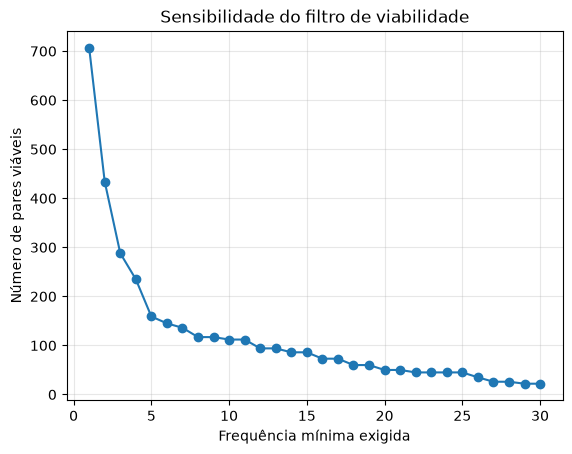

In [111]:
plt.plot(
    sensibilidade["minimo"],
    sensibilidade["viavel_total"],
    marker="o"
)

plt.xlabel("Frequência mínima exigida")
plt.ylabel("Número de pares viáveis")
plt.title("Sensibilidade do filtro de viabilidade")
plt.grid(alpha=0.3)

plt.show()